In [3]:
from google.colab import files

uploaded = files.upload()

Saving datasets.zip to datasets (1).zip


In [4]:
import zipfile

with zipfile.ZipFile("datasets.zip", "r") as zip_ref:
    zip_ref.extractall("/content/datasets")

In [5]:
import pandas as pd
import os

folder_path = "/content/datasets"

all_files = os.listdir(folder_path)

dataframes = []

for file in all_files:
    if file.endswith(".csv"):
        path = os.path.join(folder_path, file)
        df = pd.read_csv(path)
        dataframes.append(df)

In [6]:
import os

for root, dirs, files in os.walk('/content/datasets'):
    print(root, files)

/content/datasets []
/content/datasets/datasets ['Rajya_Sabha_Session_234_AU2199_1.csv', 'india_covid_data__by_district.csv', 'covid-19_day-wise count.xlsx', 'ebola-outbreaks-before-2014.xlsx', 'RS_Session_267_AS_206_C_ii.csv', 'Table-10.2-All-India_Livestock_and_Fisheries.csv', 'livestock_population_2017_18_0.csv', 'RS_Session_263_AU_92_2.ii_.csv', 'COVID-19 Cases(26-10-2021).csv', 'RS_Session_254_AU_886_1.csv', 'TEMP_ANNUAL_SEASONAL_MEAN.csv', 'rs_session_239_AU1900_1.3.csv', 'incidence_of_vaccine_preventable_diseases_in_tamil_nadu_2019.csv', 'RS_Session_262_AU_2333_2.ii_.csv', 'Table_60.csv', 'Early Detection of Monkeypox.xlsx', 'datafile (1).csv', 'covid-19_state - districts - confirmed cases.xlsx', 'Diseases_LiveStock_n.xls', 'TEMP_ANNUAL_SEASONAL_MEAN (1).csv', 'RS_Session_262_AU_2333_2.i.csv', 'livestock_census_2019_Assam.csv', 'Kerala data.xlsx', 'RS_Session_265_AU_897_A_i.csv', 'RS_249_AU2634_Annexure-II.csv', 'Table_59.csv', 'dengue_cases_in_india.csv', '2020_04_22.csv', 'INC

In [7]:
import os
import pandas as pd

folder_path = "/content/datasets"

csv_files = []

for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Total CSV files found:", len(csv_files))
print(csv_files[:5])

Total CSV files found: 43
['/content/datasets/datasets/Rajya_Sabha_Session_234_AU2199_1.csv', '/content/datasets/datasets/india_covid_data__by_district.csv', '/content/datasets/datasets/RS_Session_267_AS_206_C_ii.csv', '/content/datasets/datasets/Table-10.2-All-India_Livestock_and_Fisheries.csv', '/content/datasets/datasets/livestock_population_2017_18_0.csv']


In [8]:
dataframes = []

for file in csv_files:
    try:
        df = pd.read_csv(file, encoding='utf-8')
    except UnicodeDecodeError:

        df = pd.read_csv(file, encoding='latin1')
    dataframes.append(df)

print("Total DataFrames:", len(dataframes))

Total DataFrames: 43


In [9]:
combined_df = pd.concat(dataframes, axis=0, join='outer', ignore_index=True)

print("Combined Shape:", combined_df.shape)
combined_df.head()

Combined Shape: (105726, 698)


,State,Chickenpox,2013 - Chikungunya,2013 - CCHF,2013 - Dengue,2013 - Hand Foot and Mouth Disease,2013 - Measles,2013 - Mumps,2013 - Rubella,2013 - Viral Hepatitis,...,Surveillance_programme,Surveillance_effectiveness,Mode_of_surveillance_detection,Time_diagnosis_1st_Tx,Date_incident_surveillance_scan,PS,Time_MDM_1st_treatment,Time_decisiontotreat_1st_treatment,Prev_known_cirrhosis,Months_from_last_surveillance
0,Andaman & Nicobar Islands,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Andhra Pradesh,NaN,14.0,NaN,2.0,NaN,NaN,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arunachal Pradesh,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Assam,4.0,NaN,NaN,1.0,NaN,1.0,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Bihar,52.0,NaN,NaN,1.0,NaN,10.0,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
combined_df.to_csv("combined_dataset.csv", index=False)

In [11]:
import pandas as pd

df = pd.read_csv("combined_dataset.csv")

/tmp/ipykernel_606/1747372179.py:3: DtypeWarning: Columns (0,12,13,14,22,23,25,59,60,74,77,78,89,90,91,92,93,94,98,104,105,108,109,116,118,125,128,129,130,143,144,145,146,147,148,149,150,151,152,153,159,160,161,162,163,164,165,166,167,168,169,170,171,172,174,175,176,178,179,180,181,182,183,184,185,186,187,188,189,193,195,197,219,221,237,238,260,261,266,267,268,279,285,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,329,332,334,335,336,337,338,339,340,341,343,349,350,351,352,353,354,355,378,379,380,381,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,519,521,635,636,660,665,666,667,668,669,670,674,675,676,678,679,681,682,683,684,686,687,688,689,690,692,696) have mixed types. Specify dtype opti

In [12]:
df.head()

,State,Chickenpox,2013 - Chikungunya,2013 - CCHF,2013 - Dengue,2013 - Hand Foot and Mouth Disease,2013 - Measles,2013 - Mumps,2013 - Rubella,2013 - Viral Hepatitis,...,Surveillance_programme,Surveillance_effectiveness,Mode_of_surveillance_detection,Time_diagnosis_1st_Tx,Date_incident_surveillance_scan,PS,Time_MDM_1st_treatment,Time_decisiontotreat_1st_treatment,Prev_known_cirrhosis,Months_from_last_surveillance
0,Andaman & Nicobar Islands,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Andhra Pradesh,NaN,14.0,NaN,2.0,NaN,NaN,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arunachal Pradesh,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Assam,4.0,NaN,NaN,1.0,NaN,1.0,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Bihar,52.0,NaN,NaN,1.0,NaN,10.0,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.shape

(105726, 698)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105726 entries, 0 to 105725
Columns: 698 entries, State to Months_from_last_surveillance
dtypes: float64(467), object(231)
memory usage: 563.0+ MB


In [15]:
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)

In [16]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [17]:
at_cols = df.select_dtypes(include=['object']).columns

for col in at_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [18]:
df = df.drop_duplicates()

In [19]:
df = pd.get_dummies(df)

In [20]:
df.isnull().sum().sum()

np.int64(0)

In [21]:
df.to_csv("cleaned_dataset.csv", index=False)

In [22]:
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")

In [23]:
df.head()
df.columns

Index(['Unnamed: 0', 'V1', 'Deceased', 'Hospitalized', 'Migrated',
       'Migrated_other', 'Migrated_Other', 'Recovered',
       'Date.Announced_01/04/2020', 'Date.Announced_01/05/2020',
       ...
       'Detected.District_other State', 'Detected.District_other state',
       'Detected.District_porbandar', 'Detected.District_sheopur',
       'Detected.District_surat', 'Detected.District_surendranagar',
       'Detected.District_tapi', 'Detected.District_ujjain',
       'Detected.District_vadodara', 'Detected.District_vidisha'],
      dtype='object', length=1021)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [25]:
df = pd.read_csv("cleaned_dataset.csv")

In [26]:
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")


print(df.columns)

Index(['Unnamed: 0', 'V1', 'Deceased', 'Hospitalized', 'Migrated',
       'Migrated_other', 'Migrated_Other', 'Recovered',
       'Date.Announced_01/04/2020', 'Date.Announced_01/05/2020',
       ...
       'Detected.District_other State', 'Detected.District_other state',
       'Detected.District_porbandar', 'Detected.District_sheopur',
       'Detected.District_surat', 'Detected.District_surendranagar',
       'Detected.District_tapi', 'Detected.District_ujjain',
       'Detected.District_vadodara', 'Detected.District_vidisha'],
      dtype='object', length=1021)


In [27]:
df['Hospitalized'] = pd.to_datetime(df['Hospitalized'])

In [28]:
df = df.sort_values('Hospitalized')
df = df.set_index('Hospitalized')

In [29]:
df = pd.read_csv("cleaned_dataset.csv")
ts = df['Hospitalized']

In [30]:
from statsmodels.tsa.seasonal import STL

stl = STL(ts, period=12)

result = stl.fit()

trend = result.trend
seasonal = result.seasonal
residual = result.resid

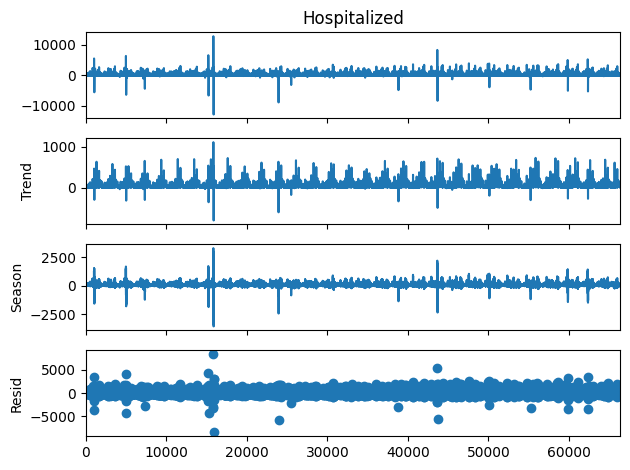

In [31]:
result.plot()
plt.show()

In [32]:
decomposed_df = pd.DataFrame({
    "trend": trend,
    "seasonal": seasonal,
    "residual": residual
})

decomposed_df = decomposed_df.dropna()

In [33]:
X = decomposed_df[['seasonal','residual']]
y = decomposed_df['trend']

In [34]:
split = int(len(decomposed_df) * 0.7)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [35]:
model = XGBRegressor(
    n_estimators=200,           #Hyperparameter
    learning_rate=0.05,
    max_depth=5
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
y_pred = model.predict(X_test)

In [37]:
decomposed_df['lag1'] = decomposed_df['trend'].shift(1)
decomposed_df['lag2'] = decomposed_df['trend'].shift(2)
decomposed_df['lag3'] = decomposed_df['trend'].shift(3)

decomposed_df = decomposed_df.dropna()

In [38]:
X = decomposed_df[['seasonal','residual','lag1','lag2','lag3']]
y = decomposed_df['trend']

In [39]:
decomposed_df['rolling_mean'] = decomposed_df['trend'].rolling(window=3).mean()

decomposed_df = decomposed_df.dropna()

In [40]:
X = decomposed_df[['seasonal','residual','lag1','lag2','lag3','rolling_mean']]
y = decomposed_df['trend']

In [41]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
split = int(len(decomposed_df)*0.9)

X_train_full = X.iloc[:split]
X_test_full = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test_full)

In [44]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor


model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.9921224434306127


In [45]:
accuracy = r2 * 100

print("Model Accuracy:", accuracy, "%")

Model Accuracy: 99.21224434306127 %
